In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Image

# Beep-Beep PAYMENT DECLINED - 
# Predicting Credit Card Default

##### By Shuheng Gao

#### **Now imagine**

Your are a credit card sales representative in a bank of nowhere. You are sitting in a small office sharing one desk with three colleagues of yours. 

Your boss just evaluated your portfolio, and you are COOKED because 80% of your clients are not paying the credit card at all!!! Now, there are two options in front of you, bearing the sarcastic look from your colleagues, and wait untill one day your boss call you to a one-to-one meeting, and kick you out of banking industry. 

**OR**, trust the power of ~~Natural Recursion~~ Machine Learning, and comeback as a lengend.

<small>everyone would choose the second option right?</small>

However, to save your job using Machine Learning, we first need to identify what kind of problem is this.

In the circumstance here, we need to use the known information about our clients to give a prediction on whether they will pay the credit card before due date. Thus, we will use the [classification](https://en.wikipedia.org/wiki/Classification) technique in [Supervised Learning](https://en.wikipedia.org/wiki/Supervised_learning) to solve the problem.



#### **Explore the Dataset**

Let's have look on the data the company collected on the credit card payment status of the clients

[Here](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset) are the information of the data, you can find the description of every column below and download the dataset to play if you want.

In [2]:
data_set = pd.read_csv("UCI_Credit_Card.csv", index_col="ID")
data_set.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Do you see any pattern in the first five customers we have here? Of course you do not because no one can! That's why we need to carry out a Machine Learning pipeline to find that pattern.

We are depending on the last column of the dataset, which is default.payment.next.month, to tell us if the customer can pay the credit card on time. 

This is called [**target**](https://h2o.ai/wiki/target-variable/) in our problem, the main goal of our model is to use the data from the rest of the columns to predict the target so that we can use the result to determine whether we should grant a credit card to the customer. Those columns are called [**features**](https://en.wikipedia.org/wiki/Feature_(machine_learning))

Let's look at the histogram of some of the features and their relationship with the target.

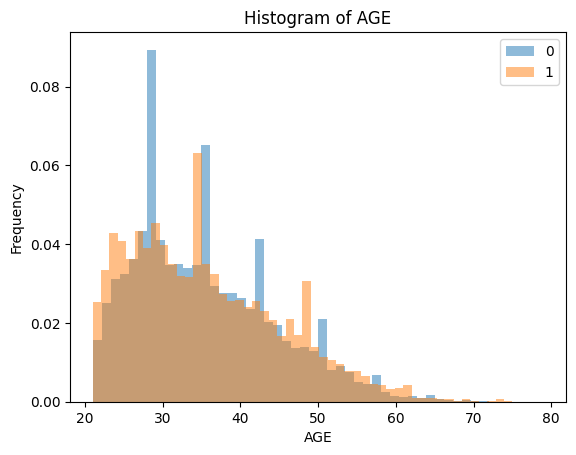

In [3]:
Image("img/output.png")

From the histogram of AGE, we can see that the customers in age around 25-30 are more likely to pay on time.

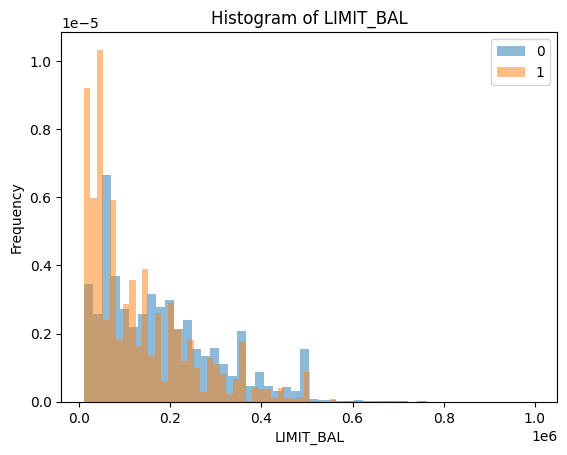

In [4]:
Image("img/limitbaloutput.png")

From the histogram of LIMIT_BAL, we can see that the customers with lower credit limit are more likely to have default payment.

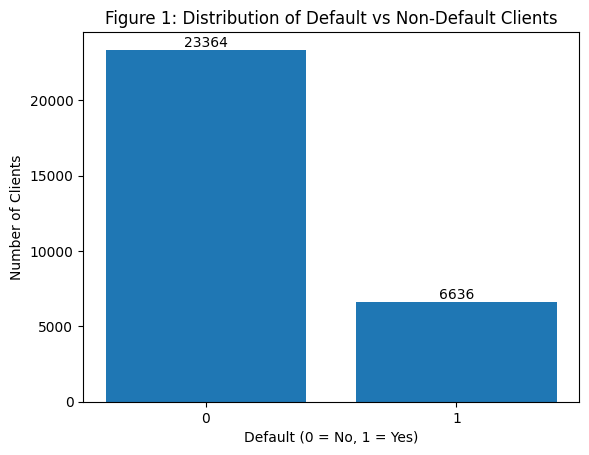

In [5]:
Image("img/classdistribution.png")

The distribution above shows that the class of target is imbalanced, we will see the effect of it later.

In this phase of Machine Learning problem, we need to examine more information of the dataset to find the hidden pattern of the target and features, so that we can apply these findings to the subsequent steps of the training.

#### **Model Approach**

First, carry out a baseline model. Our model approaches should have better performance than the baseline, or it would be really useless (I mean really).

The dummy classifier will predict all samples as the majority.

Below is the performance of it.

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>fit_time</th>
      <th>score_time</th>
      <th>test_score</th>
      <th>train_score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>0.024238</td>
      <td>0.005114</td>
      <td>0.776905</td>
      <td>0.776726</td>
    </tr>
    <tr>
      <th>1</th>
      <td>0.010726</td>
      <td>0.004287</td>
      <td>0.776905</td>
      <td>0.776726</td>
    </tr>
    <tr>
      <th>2</th>
      <td>0.011634</td>
      <td>0.004830</td>
      <td>0.776667</td>
      <td>0.776786</td>
    </tr>
    <tr>
      <th>3</th>
      <td>0.011600</td>
      <td>0.004399</td>
      <td>0.776667</td>
      <td>0.776786</td>
    </tr>
    <tr>
      <th>4</th>
      <td>0.010507</td>
      <td>0.004063</td>
      <td>0.776667</td>
      <td>0.776786</td>
    </tr>
  </tbody>
</table>
</div>

###### The dummy classifier has a decent performance due to the imbalance of our data.

Now, we gotta pick the suitable model to tackle the problem here. 

For the most of the time, we can train different models on the same data and choose the model with the best performance.

I tried four different models, RandomForest, LightGBM, KNN and SVC-RBF. 

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>Train Accuracy</th>
      <th>Test Accuracy</th>
      <th>Train F1</th>
      <th>Test F1</th>
      <th>Train Precision</th>
      <th>Test Precision</th>
      <th>Train Recall</th>
      <th>Test Recall</th>
      <th>Train AUC</th>
      <th>Test AUC</th>
      <th>Fit_time</th>
      <th>Score_time</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>RandomForest</td>
      <td>0.999333</td>
      <td>0.814190</td>
      <td>0.998506</td>
      <td>0.473127</td>
      <td>0.999359</td>
      <td>0.645737</td>
      <td>0.997654</td>
      <td>0.373723</td>
      <td>0.999997</td>
      <td>0.761852</td>
      <td>2.956134</td>
      <td>0.114656</td>
    </tr>
    <tr>
      <th>1</th>
      <td>LightGBM</td>
      <td>0.853905</td>
      <td>0.819429</td>
      <td>0.579869</td>
      <td>0.479821</td>
      <td>0.809813</td>
      <td>0.672376</td>
      <td>0.451632</td>
      <td>0.373080</td>
      <td>0.903300</td>
      <td>0.778118</td>
      <td>0.124549</td>
      <td>0.022885</td>
    </tr>
    <tr>
      <th>2</th>
      <td>KNN</td>
      <td>0.844429</td>
      <td>0.793429</td>
      <td>0.579013</td>
      <td>0.438091</td>
      <td>0.731262</td>
      <td>0.557835</td>
      <td>0.479255</td>
      <td>0.360710</td>
      <td>0.881670</td>
      <td>0.703641</td>
      <td>0.012707</td>
      <td>0.106601</td>
    </tr>
    <tr>
      <th>3</th>
      <td>SVC</td>
      <td>0.824286</td>
      <td>0.819333</td>
      <td>0.482143</td>
      <td>0.467458</td>
      <td>0.704785</td>
      <td>0.683920</td>
      <td>0.366414</td>
      <td>0.355161</td>
      <td>0.784204</td>
      <td>0.719540</td>
      <td>4.426527</td>
      <td>1.792671</td>
    </tr>
  </tbody>
</table>
</div>

Hmmmm, looks like LightGBM has the highest Test accuracy. SVC is also doing great but its train/score time is too long and the F1 score is not ideal. Thus, we will choose LightGBM as our model.


#### Final Results

The LightGBM model now has a test accuracy of 0.819 running on default hyperparameters. Do we still have a chance to improve it? 

I carried out a hyperparameter optimization and got similar scorings:

fit_time           0.132054

score_time         0.026210

test_accuracy      0.818524

train_accuracy     0.840798

test_f1            0.476182

train_f1           0.541028

test_recall        0.369454

train_recall       0.420328

test_precision     0.669862

train_precision    0.759001

test_roc_auc       0.782601

train_roc_auc      0.867151

What about feature selections?

Selected Feature:

        'standardscaler__LIMIT_BAL', 'standardscaler__AGE',

       'standardscaler__PAY_0', 'standardscaler__PAY_2',

       'standardscaler__PAY_3', 'standardscaler__PAY_4',

       'standardscaler__PAY_6', 'standardscaler__BILL_AMT1',

       'standardscaler__BILL_AMT2', 'standardscaler__BILL_AMT3',

       'standardscaler__BILL_AMT4', 'standardscaler__BILL_AMT5',

       'standardscaler__BILL_AMT6', 'standardscaler__PAY_AMT1',

       'standardscaler__PAY_AMT2', 'standardscaler__PAY_AMT3',

       'standardscaler__PAY_AMT4', 'standardscaler__PAY_AMT5',

       'standardscaler__PAY_AMT6', 'standardscaler__DELAY_COUNT',

       'standardscaler__MAX_CREDIT_USAGE_RATIO',

       'ordinalencoder__EDUCATION', 'onehotencoder-1__SEX_2',

       'onehotencoder-2__MARRIAGE_1', 'onehotencoder-2__MARRIAGE_2'])

The feature selection using RFECV shows that the LightGBM actually selected almost all of the features here.

Looks like this is the end for the accuracy...

However, we don't just evaluate the performance of the model by solely accuracy, we can see that LightGBM actually has decent F1 score and recall. This means that the model can identify the risky customers for us!

Therefore, although we might reject some new customers that actually can pay their credit card, we can use this conservative strategy to improve our performance!

In addition, if our boss is unhappy about rejecting too many customers, we can explain our reasoning by showing them the SHAP plot we have for the rejected customer.

#### Example:

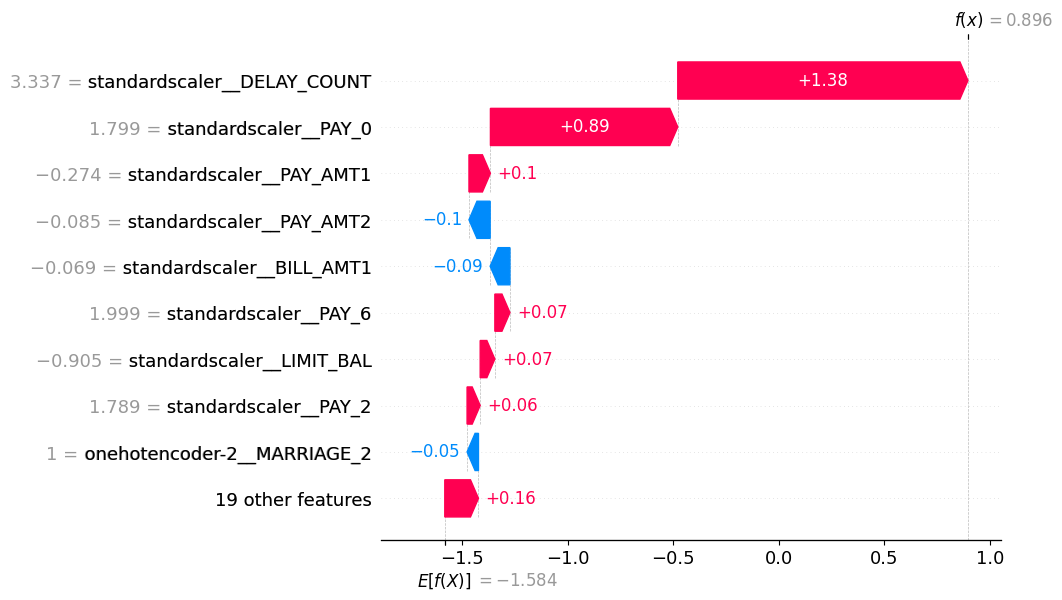

In [6]:
Image("img/shapdefault.png")

This is a SHAP waterfall plot for a customer that was not able to pay the credit card on time and also successfully predicted by our model.

We can see that the number of delay payment of this customer in the data collecting months is quite high, this drives our model towards positive, which is the direction of predicting default payment. 

So, the next time your boss asks for the reason of rejecting a specific customer, you can use this plot instead of just saying it's ML magic!

#### Caveats

1. The effect of class imbalance

    In the dataset, the ratio of two target classes is high as 4:1, this makes the even the baseline model can give a decent accuracy score. Although we can still use this model considering the improvment in F1 score and recall, the imbalance is still a significant problem that preventing us from better overall performance in the model.

2. The choice of model

    Due to machine limit and time limit of the project, I was not able to try other kinds of models or fine-tune some of the models, for example, although KNN and SVC showed close performance to the LightGBM, the cost of training time of the two models make it hard to fine-tune their hyperparameters. In addition, the size of the dataset is sufficient for neural network model to train and predict, but I was not able to use it.

3. Limited feature in the dataset

    The features in the dataset only consist financial data and very limited personal data of the customers. If the dataset can be more specific about informations like employment status, income status and savings status of the customers, the model could consider very variables and might give better outcomes.